# Attention, Virality, and Digital Culture
---
### Opening Question
**How does attention move across major social media platforms, and what patterns seem to support virality?**

### Objective
This notebook explores how attention flows across Twitter, Reddit, Instagram, YouTube, TikTok, and Facebook. The dataset contains posts with engagement metrics, sentiment details, and cross-platform spread indicators.

The aim is to understand which kinds of content receive attention, whether some platforms amplify certain types of engagement, and what factors might separate viral posts from the rest.

### Dataset Overview
- **Source**: Multi-Platform Social Sentiment Evolution dataset from [Kaggle](https://www.kaggle.com/datasets/benjaminneil/social-sentiment-evolution).
- **Variables**: platform, topic, sentiment, likes, shares, comments, views, hour_of_day, is_weekend, viral_coefficient, cross_platform_spread, verified, follower_count
- **Analysis Approach**: Exploratory Data Analysis [EDA] with focus on cross-platform attention patterns, virality indicators, and engagement dynamics through visualisation and statistical summaries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


In [2]:
# colour scheme
primary = "#0D47A1"
secondary = "#90CAF9"

gradient = ["#BBDEFB", "#90CAF9", "#64B5F6", "#42A5F5", "#2196F3", "#1E88E5", "#1565C0", "#0D47A1"]
# accent colours
mangoacc = "#ff9f43"
pinkacc = "#ff6b81"
skyacc = "#74b9ff"

## 1. Dataset Loading and Overview

I will begin by loading the dataset and checking its basic structure. This gives a first look at what the file contains before the actual analysis begins.

#### Step 1: What does the dataset look like at first glance?

Loading the CSV file and inspecting its basic shape and size.

Functions used:
1. read_csv()
2. shape


In [3]:
# load the dataset
path = "trendsanalysis.csv"
file = pd.read_csv(path)


In [4]:
print(f"Dataset shape: {file.shape}")

Dataset shape: (150000, 31)


In [5]:
print(f"\nTotal records: {file.shape[0]}")


Total records: 150000


### 1.1 First Look at the Data

#### Step 2: What do the first and last records reveal?

The first and last five records are displayed to understand the dataset layout.

Functions used:
1. head()
2. tail()


In [6]:
print("First 5 records:")
file.head()

First 5 records:


,post_id,platform,timestamp,date,hour_of_day,day_of_week,is_weekend,user_id,followers,account_age_days,...,shares,comments,views,total_engagement,engagement_rate_per_1k_followers,hours_since_post,viral_coefficient,cross_platform_spread,toxicity_score,location
0,TIK20250419000000,TikTok,2025-04-19 01:56:55,2025-04-19,1,5,1,user_426711,137,306,...,0,0,0,0,0.00,37.1,0.00,0,29.4,Asia
1,TWI20250419000001,Twitter,2025-04-19 05:34:09,2025-04-19,5,5,1,user_221610,1974,2310,...,0,0,105,3,1.52,37.1,0.08,0,3.3,South America
2,INS20250419000002,Instagram,2025-04-19 06:33:36,2025-04-19,6,5,1,user_7998,6471,1990,...,0,0,26,2,0.31,21.0,0.10,0,25.3,Europe
3,INS20250419000003,Instagram,2025-04-19 06:42:16,2025-04-19,6,5,1,user_313440,1366,2057,...,16,8,3057,98,71.74,47.1,2.08,0,3.1,Europe
4,RED20250419000004,Reddit,2025-04-19 06:46:49,2025-04-19,6,5,1,user_23343,1349,1445,...,0,0,0,0,0.00,10.0,0.00,0,52.7,Asia


### 1.2 Data Types and Column Information

#### Step 3: What kind of columns does the dataset contain?

This step checks the column names, data types, and basic structure of the dataset.

Functions used:
1. info()
2. columns [used with tolist() for cleaner display]


In [7]:
print("Dataset Info:")
file.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   post_id                           150000 non-null  str    
 1   platform                          150000 non-null  str    
 2   timestamp                         150000 non-null  str    
 3   date                              150000 non-null  str    
 4   hour_of_day                       150000 non-null  int64  
 5   day_of_week                       150000 non-null  int64  
 6   is_weekend                        150000 non-null  int64  
 7   user_id                           150000 non-null  str    
 8   followers                         150000 non-null  int64  
 9   account_age_days                  150000 non-null  int64  
 10  verified                          150000 non-null  int64  
 11  topic                             150000 non-null

In [8]:
print("\nColumn Names:")
file.columns.tolist()


Column Names:


['post_id',
 'platform',
 'timestamp',
 'date',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'user_id',
 'followers',
 'account_age_days',
 'verified',
 'topic',
 'language',
 'content_length',
 'media_type',
 'num_hashtags',
 'sentiment_category',
 'sentiment_positive',
 'sentiment_negative',
 'sentiment_neutral',
 'likes',
 'shares',
 'comments',
 'views',
 'total_engagement',
 'engagement_rate_per_1k_followers',
 'hours_since_post',
 'viral_coefficient',
 'cross_platform_spread',
 'toxicity_score',
 'location']

## 2. Data Quality Checks

Before moving into analysis, I need to check whether the dataset has missing values, duplicate rows, or any obvious issues. Clean data makes the rest of the work much less painful, which is always appreciated.

#### Step 4: Is the dataset ready for analysis?

Running completeness and integrity checks on the dataset.

Functions used:
1. isnull()
2. duplicated()
3. describe()


In [9]:
# missing values check
print("Missing Values:")
missing = file.isnull().sum()
missing_pct = (missing / len(file)) * 100
missing_file = pd.DataFrame({"Column": missing.index, "Missing Count": missing.values, "Missing %": missing_pct.values})
print(missing_file[missing_file["Missing Count"] > 0] if missing_file["Missing Count"].sum() > 0 else "No missing values found!")
print(f"\nTotal missing values in dataset: {file.isnull().sum().sum()}")


Missing Values:
No missing values found!

Total missing values in dataset: 0


In [10]:
# duplicates check
print(f"Number of duplicate rows: {file.duplicated().sum()}")
print(f"Number of unique records: {len(file.drop_duplicates())}")


Number of duplicate rows: 0
Number of unique records: 150000


In [11]:
# summary of variables
print("\nDataset Statistics:")
file.describe(include="all").round(2)



Dataset Statistics:


,post_id,platform,timestamp,date,hour_of_day,day_of_week,is_weekend,user_id,followers,account_age_days,...,shares,comments,views,total_engagement,engagement_rate_per_1k_followers,hours_since_post,viral_coefficient,cross_platform_spread,toxicity_score,location
count,150000,150000,150000,150000,150000.00,150000.00,150000.00,150000,1.500000e+05,150000.00,...,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000
unique,150000,6,148242,184,NaN,NaN,NaN,129556,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,TIK20250419000000,Twitter,2025-04-21 19:24:16,2025-09-22,NaN,NaN,NaN,user_283647,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North America
freq,1,44676,3,4286,NaN,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52409
mean,NaN,NaN,NaN,NaN,16.65,2.88,0.28,NaN,2.553545e+04,1842.49,...,52.82,30.18,9790.22,437.43,57.27,24.04,55.55,0.01,23.81,NaN
std,NaN,NaN,NaN,NaN,3.84,2.04,0.45,NaN,6.501271e+05,1044.49,...,406.56,238.39,76088.02,3133.85,321.48,13.82,1339.22,0.11,25.68,NaN
min,NaN,NaN,NaN,NaN,1.00,0.00,0.00,NaN,0.000000e+00,30.00,...,0.00,0.00,0.00,0.00,0.00,0.10,0.00,0.00,0.00,NaN
25%,NaN,NaN,NaN,NaN,14.00,1.00,0.00,NaN,9.100000e+01,938.00,...,0.00,0.00,0.00,0.00,0.00,12.10,0.00,0.00,1.08,NaN
50%,NaN,NaN,NaN,NaN,17.00,3.00,0.00,NaN,4.810000e+02,1848.00,...,0.00,0.00,78.00,3.00,4.18,24.10,0.17,0.00,14.80,NaN
75%,NaN,NaN,NaN,NaN,20.00,5.00,1.00,NaN,2.766250e+03,2746.00,...,4.00,2.00,825.00,40.00,27.03,36.00,2.39,0.00,38.50,NaN


#### Step 5: What do the quality checks reveal?

The checks above show whether the dataset needs cleaning before visualisation. If missing values or duplicates are present, they should be reviewed before final conclusions are made.

**Key Takeaway**: The dataset should be assessed for completeness, consistency, and usability before any analytical conclusions are drawn.


## 3. Platform Attention Analysis

This section compares engagement across platforms. Since attention can mean likes, shares, comments, or views, I will look at more than one metric.

#### Research Questions for This Section:
- Which platforms generate the most attention?
- Do different platforms dominate different engagement metrics?
- How does platform design influence engagement type?

#### Step 6: Which platforms generate the most attention?

Analysing average engagement by platform across multiple metrics.

Functions used:
1. groupby()
2. mean()
3. sort_values()


In [12]:
# platform engagement summary
print("Average Engagement by Platform:")
platform_engagement = file.groupby("platform")[["likes", "shares", "comments", "views"]].mean().round(0)
print(platform_engagement)
print(f"\nPercentage Distribution:")
print((platform_engagement / platform_engagement.sum() * 100).round(1))


Average Engagement by Platform:
            likes  shares  comments    views
platform                                    
Facebook    234.0    35.0      19.0   6131.0
Instagram   341.0    51.0      29.0   9412.0
Reddit       38.0     5.0       3.0   1068.0
TikTok      559.0    85.0      50.0  15615.0
Twitter     185.0    28.0      16.0   5081.0
YouTube    1366.0   202.0     115.0  37808.0

Percentage Distribution:
           likes  shares  comments  views
platform                                 
Facebook     8.6     8.6       8.2    8.2
Instagram   12.5    12.6      12.5   12.5
Reddit       1.4     1.2       1.3    1.4
TikTok      20.5    20.9      21.6   20.8
Twitter      6.8     6.9       6.9    6.8
YouTube     50.2    49.8      49.6   50.3


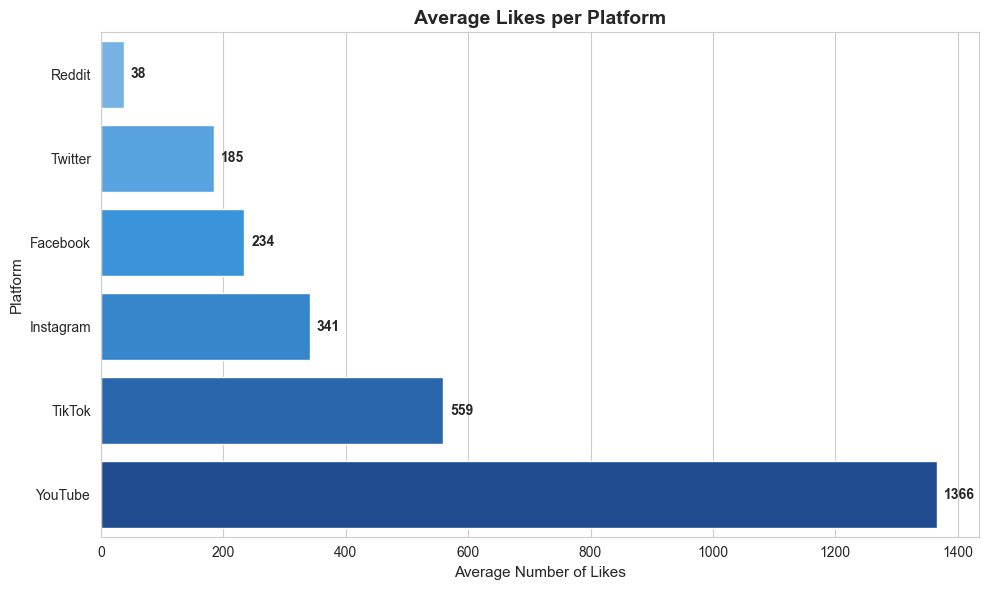

In [13]:
# visualisation: platform likes
plt.figure(figsize=(10, 6))
platform_likes = file.groupby("platform")["likes"].mean().sort_values(ascending=True)
ax = sns.barplot(y=platform_likes.index, x=platform_likes.values, palette=gradient[-len(platform_likes):], hue=platform_likes.index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Likes per Platform", fontsize=14, fontweight="bold")
plt.xlabel("Average Number of Likes", fontsize=11)
plt.ylabel("Platform", fontsize=11)
plt.tight_layout()
plt.show()


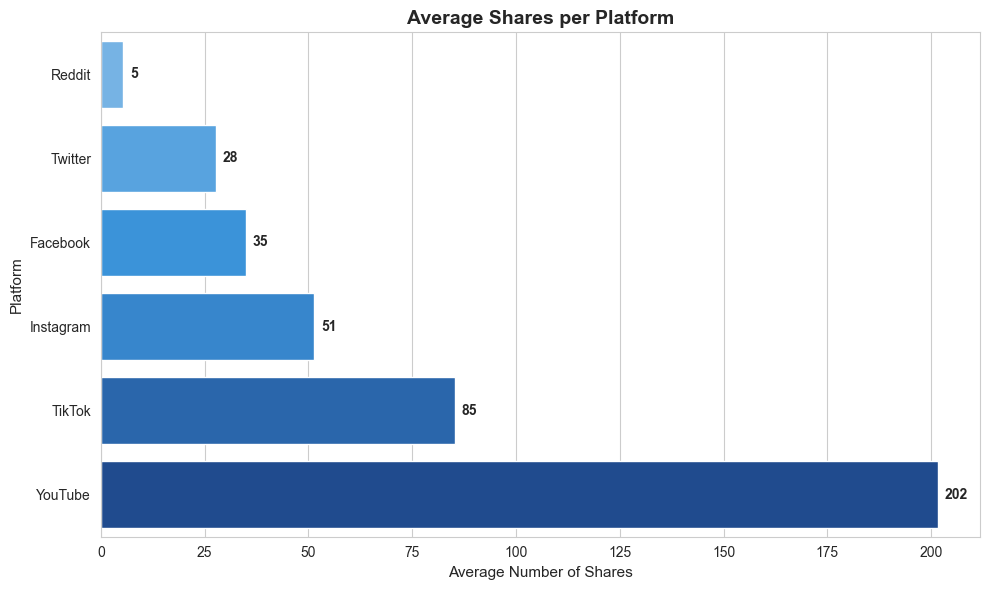

In [14]:
# visualisation: platform shares
plt.figure(figsize=(10, 6))
platform_shares = file.groupby("platform")["shares"].mean().sort_values(ascending=True)
ax = sns.barplot(y=platform_shares.index, x=platform_shares.values, palette=gradient[-len(platform_shares):], hue=platform_shares.index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Shares per Platform", fontsize=14, fontweight="bold")
plt.xlabel("Average Number of Shares", fontsize=11)
plt.ylabel("Platform", fontsize=11)
plt.tight_layout()
plt.show()


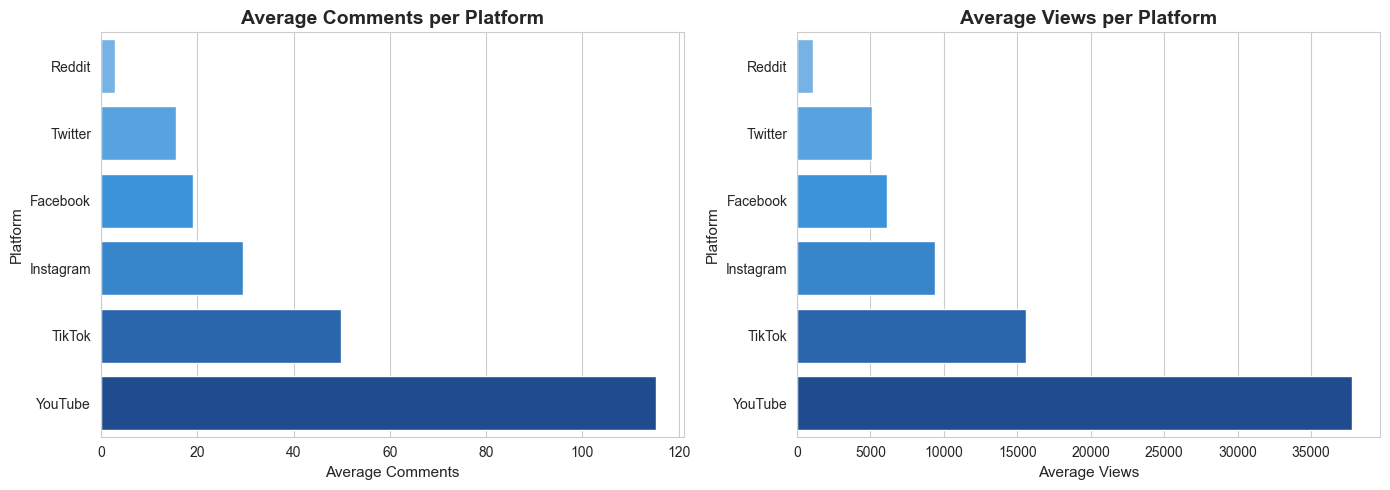

In [15]:
# visualisation: platform comments and views
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platform_comments = file.groupby("platform")["comments"].mean().sort_values(ascending=True)
sns.barplot(y=platform_comments.index, x=platform_comments.values, palette=gradient[-len(platform_comments):], hue=platform_comments.index, legend=False, ax=axes[0])
axes[0].set_title("Average Comments per Platform", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Average Comments", fontsize=11)
axes[0].set_ylabel("Platform", fontsize=11)

platform_views = file.groupby("platform")["views"].mean().sort_values(ascending=True)
sns.barplot(y=platform_views.index, x=platform_views.values, palette=gradient[-len(platform_views):], hue=platform_views.index, legend=False, ax=axes[1])
axes[1].set_title("Average Views per Platform", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Average Views", fontsize=11)
axes[1].set_ylabel("Platform", fontsize=11)

plt.tight_layout()
plt.show()


**Observation**: Different platforms can lead in different metrics. YouTube may dominate views because it is video-focused, while TikTok may perform strongly in likes. Reddit often creates more comments because discussion is a major part of the platform.


**Key Takeaway**: There is no single most engaging platform. Engagement depends on what is being measured, because a like, share, comment, and view all show different forms of attention.


## 4. Topic and Attention Analysis

This section checks how topics perform across platforms. It helps show whether a topic does well everywhere or mainly on specific platforms.

#### Research Questions for This Section:
- Do certain topics capture more attention than others?
- Which topics generate the most discussion?
- Does topic performance vary by platform?

#### Step 7: Do certain topics capture more attention than others?

Using a heatmap to visualise topic-platform engagement patterns.

Functions used:
1. pivot_table()
2. fillna()
3. heatmap()


In [16]:
# topic-platform engagement
print("Topic Performance Across Platforms (Average Likes):")
topic_platform_likes = file.pivot_table(values="likes", index="topic", columns="platform", aggfunc="mean").fillna(0)
topic_platform_likes.round(2)


Topic Performance Across Platforms (Average Likes):


platform,Facebook,Instagram,Reddit,TikTok,Twitter,YouTube
topic,,,,,,
AI/ML,289.43,353.39,27.43,592.12,205.63,1474.43
Business,236.42,278.22,41.95,503.64,163.11,1327.59
Climate,168.10,385.15,41.77,583.09,185.11,1292.82
Education,183.05,354.34,38.61,629.31,187.21,1387.45
Entertainment,211.22,374.37,34.21,464.45,190.43,1688.56
Fashion,283.08,346.70,39.39,512.53,182.95,1353.79
Finance,281.82,294.05,33.51,561.26,206.11,1339.07
Food,296.92,348.14,44.37,458.02,157.19,1031.21
Gaming,294.04,339.50,37.05,614.29,174.73,1401.81


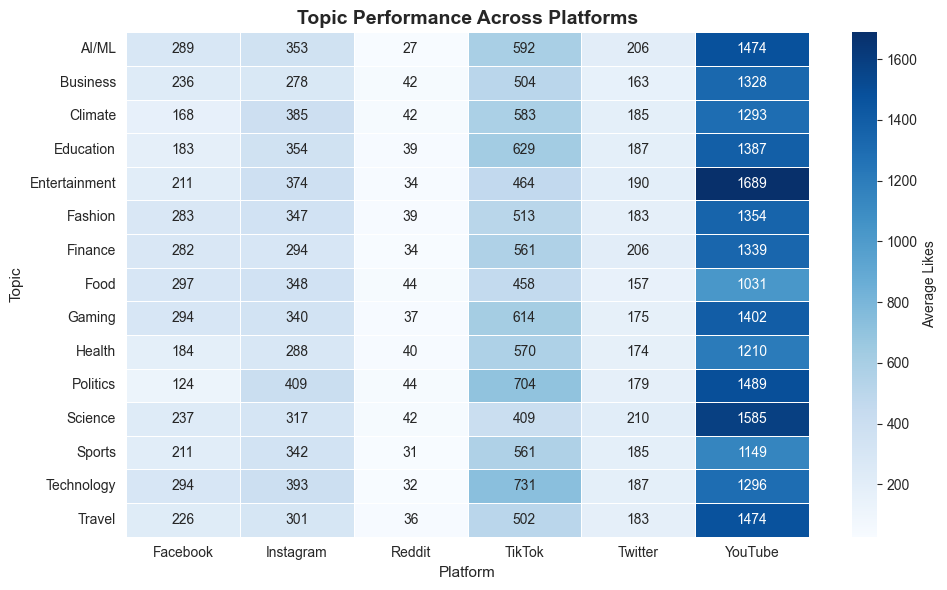

In [42]:
# visualisation: topic performance heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(topic_platform_likes, annot=True, cmap="Blues", fmt=".0f", cbar_kws={"label": "Average Likes"}, linewidths=0.5)
plt.title("Topic Performance Across Platforms", fontsize=14, fontweight="bold")
plt.xlabel("Platform", fontsize=11)
plt.ylabel("Topic", fontsize=11)
plt.tight_layout()
plt.show()


### 4.1 Topic Discussion Analysis

#### Step 8: Which topics generate the most discussion?

Comments are useful for studying discussion because they usually need more effort than likes. This step checks total comments by topic.

Functions used:
1. groupby()
2. sum()
3. sort_values()


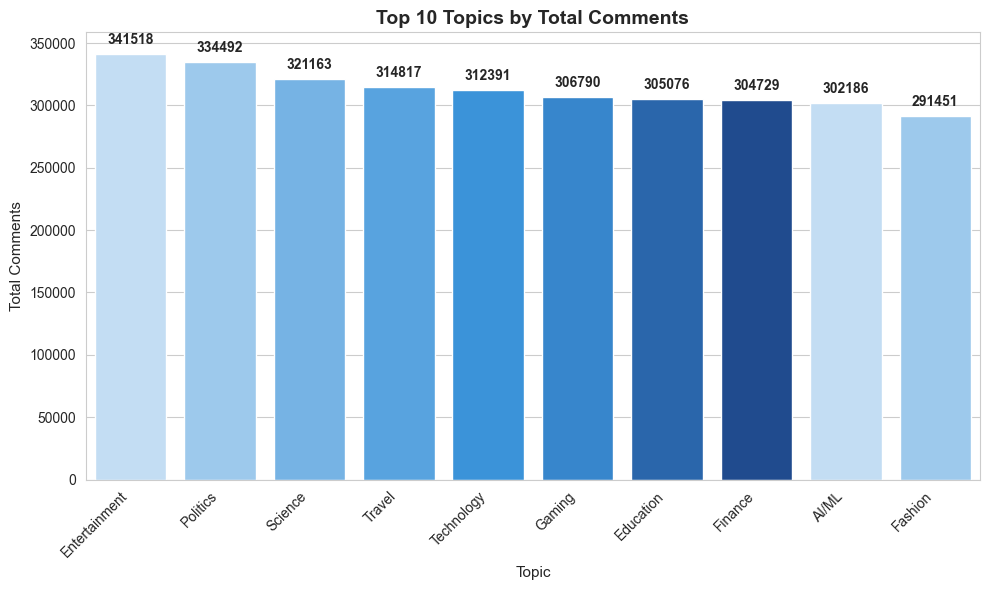

In [18]:
# visualisation: top topics by comments
topic_comments = file.groupby("topic")["comments"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=topic_comments.head(10).index, y=topic_comments.head(10).values, palette=gradient, hue=topic_comments.head(10).index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Top 10 Topics by Total Comments", fontsize=14, fontweight="bold")
plt.xlabel("Topic", fontsize=11)
plt.ylabel("Total Comments", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Observation**: Entertainment, technology, and gaming may perform well across several platforms. Politics can create strong discussion on platforms where debate is common. Some topics work well in one space but not another, which shows that audience culture matters.


**Key Takeaway**: Topic and platform work together. The same topic can receive very different attention depending on where it is posted.


## 5. Timing and Engagement Analysis

This section checks whether posts receive different engagement depending on the hour of the day and whether they are posted on weekdays or weekends.

#### Research Questions for This Section:
- Does posting time affect attention?
- Are weekend posts more engaging than weekday posts?
- Is there an optimal posting window?

#### Step 9: Does posting time affect attention?

Analysing hourly and weekend/weekday engagement patterns.

Functions used:
1. groupby()
2. mean()
3. plot()


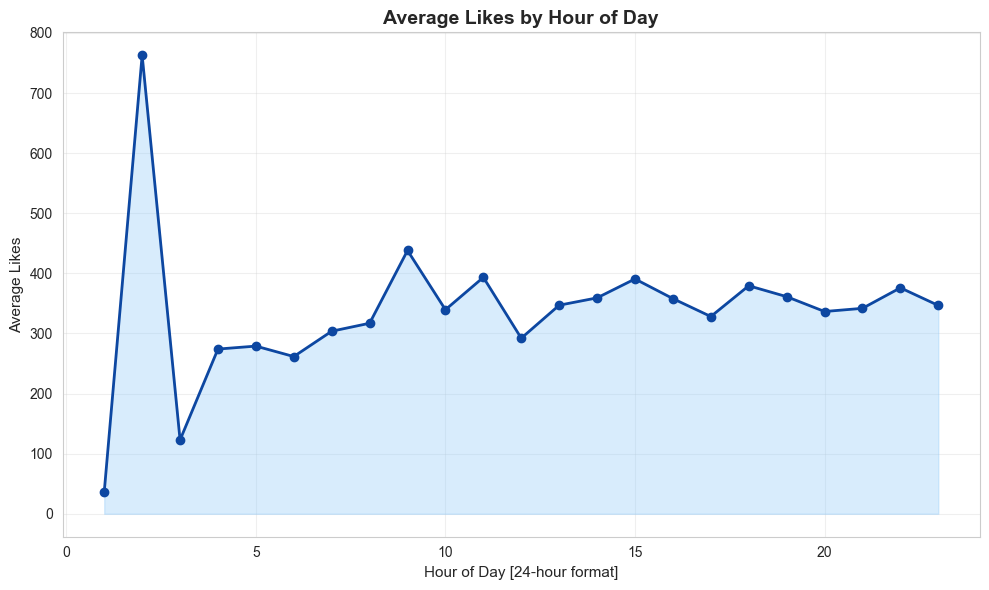

In [19]:
# visualisation: hourly engagement
plt.figure(figsize=(10, 6))
hourly_likes = file.groupby("hour_of_day")["likes"].mean()

plt.plot(hourly_likes.index, hourly_likes.values, marker="o", linestyle="-", color=primary, linewidth=2)
plt.fill_between(hourly_likes.index, hourly_likes.values, color=secondary, alpha=0.35)
plt.title("Average Likes by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day [24-hour format]", fontsize=11)
plt.ylabel("Average Likes", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
print("Average Engagement: Weekend vs Weekday:")
weekend_engagement = file.groupby("is_weekend")[["likes", "shares", "comments"]].mean()
weekend_engagement.index = ["Weekday", "Weekend"]
weekend_engagement.round(2)


Average Engagement: Weekend vs Weekday:


,likes,shares,comments
Weekday,357.04,53.40,30.34
Weekend,347.57,51.33,29.75


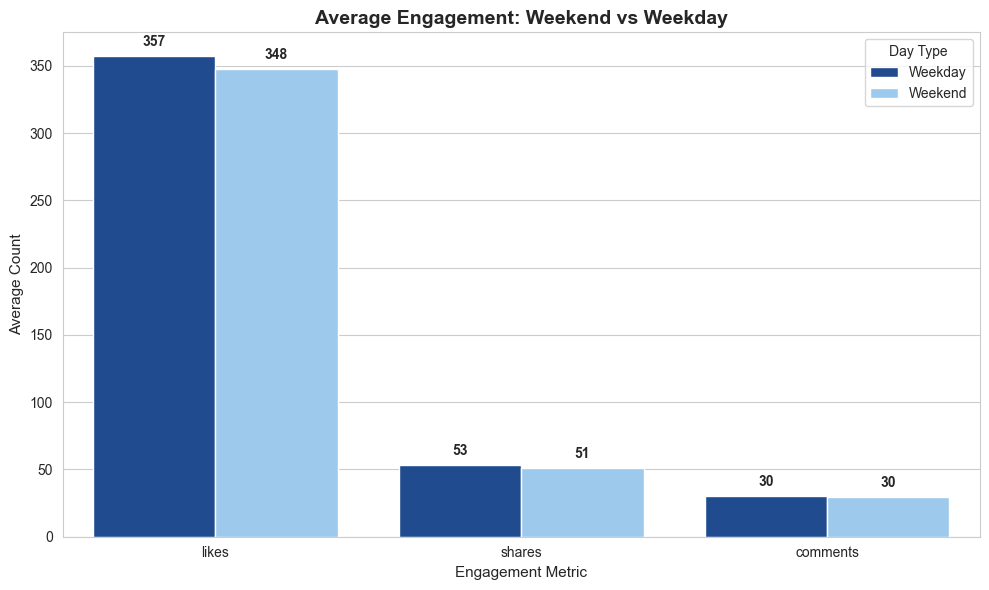

In [21]:
# visualisation: weekend vs weekday
weekend_plot = weekend_engagement.reset_index().rename(columns={"index": "Day Type"})
weekend_melted = weekend_plot.melt(id_vars="Day Type", var_name="Metric", value_name="Average")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=weekend_melted, x="Metric", y="Average", hue="Day Type", palette=[primary, secondary])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Engagement: Weekend vs Weekday", fontsize=14, fontweight="bold")
plt.xlabel("Engagement Metric", fontsize=11)
plt.ylabel("Average Count", fontsize=11)
plt.tight_layout()
plt.show()


**Observation**: Engagement may rise during certain hours, especially when users are more active. Weekend posts may receive more likes and comments on average, although the difference may not be very large.


**Key Takeaway**: Timing seems to matter, but it is not everything. A weak post at the perfect time is still a weak post, which is unfortunate but fair.


## 6. Cross-Platform Spread Analysis

This section compares posts that spread across several platforms with posts that remain limited to one platform.

#### Research Questions for This Section:
- What separates high-spread content from low-spread content?
- How are engagement and virality indicators related?
- Does cross-platform spread guarantee higher engagement?

#### Step 10: What separates high-spread content from low-spread content?

Comparing engagement metrics between posts that spread widely vs. those that stay localised.

Functions used:
1. boolean indexing
2. mean()
3. DataFrame()


In [22]:
# cross-platform spread comparison
median_spread = file["cross_platform_spread"].median()
high_spread = file[file["cross_platform_spread"] > median_spread]
low_spread = file[file["cross_platform_spread"] <= median_spread]
print(f"High spread posts count: {len(high_spread)}")
print(f"Low spread posts count: {len(low_spread)}")


High spread posts count: 1946
Low spread posts count: 148054


In [23]:
print("Engagement Comparison: High Spread vs Low Spread:")
high_spread_avg = high_spread[["likes", "shares", "comments", "views"]].mean()
low_spread_avg = low_spread[["likes", "shares", "comments", "views"]].mean()

spread_comparison = pd.DataFrame({
    "High Spread": high_spread_avg,
    "Low Spread": low_spread_avg
}).round(2)
spread_comparison


Engagement Comparison: High Spread vs Low Spread:


,High Spread,Low Spread
likes,6746.06,270.41
shares,1014.36,40.19
comments,563.85,23.17
views,189440.41,7428.92


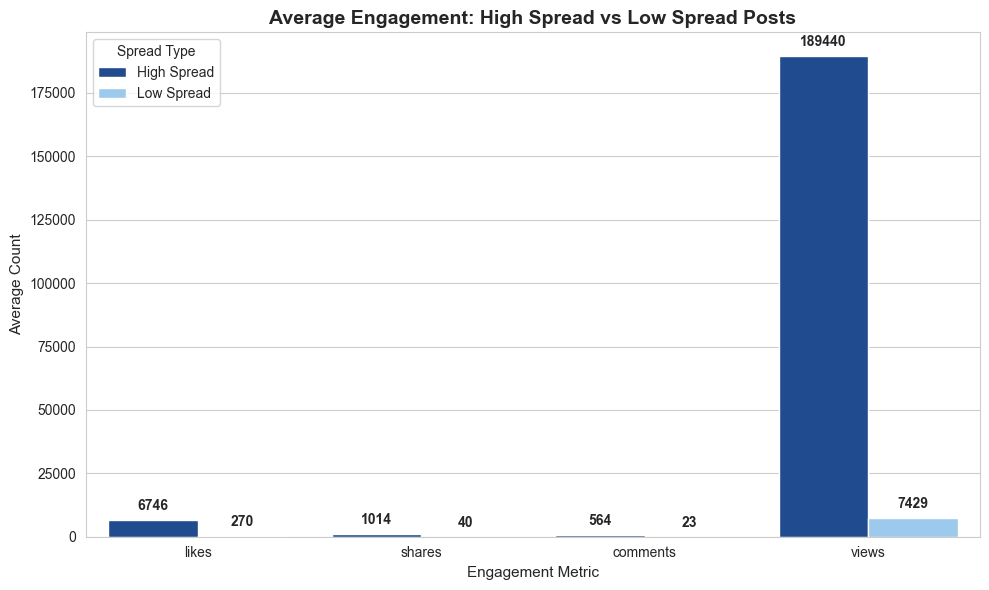

In [24]:
# visualisation: spread comparison
spread_melted = spread_comparison.reset_index().melt(id_vars="index", var_name="Spread Type", value_name="Average")
spread_melted.rename(columns={"index": "Metric"}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=spread_melted, x="Metric", y="Average", hue="Spread Type", palette=[primary, secondary])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Engagement: High Spread vs Low Spread Posts", fontsize=14, fontweight="bold")
plt.xlabel("Engagement Metric", fontsize=11)
plt.ylabel("Average Count", fontsize=11)
plt.tight_layout()
plt.show()


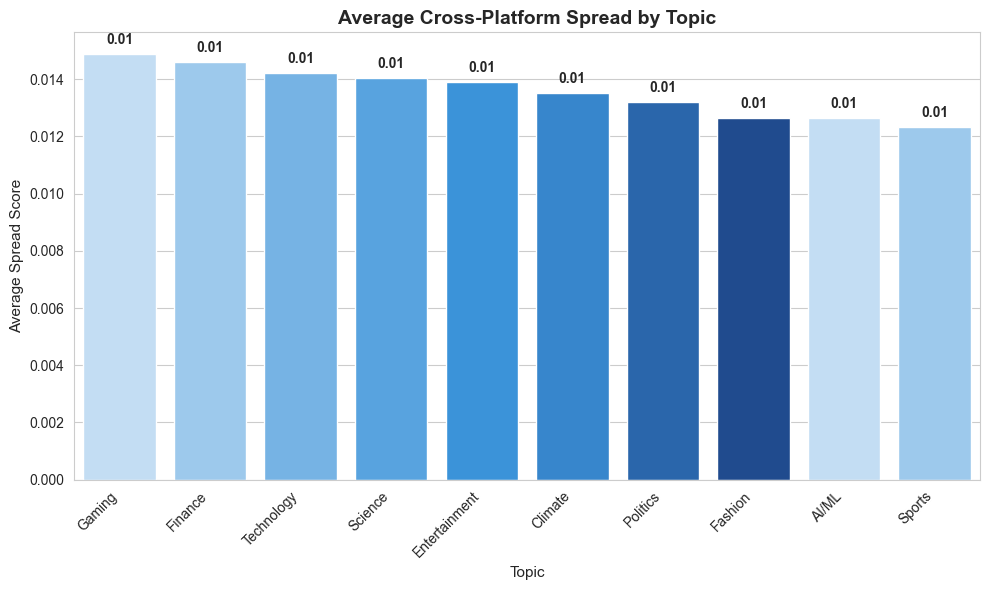

In [25]:
# visualisation: topic spread
plt.figure(figsize=(10, 6))
topic_spread = file.groupby("topic")["cross_platform_spread"].mean().sort_values(ascending=False)

ax = sns.barplot(x=topic_spread.head(10).index, y=topic_spread.head(10).values, palette=gradient, hue=topic_spread.head(10).index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Cross-Platform Spread by Topic", fontsize=14, fontweight="bold")
plt.xlabel("Topic", fontsize=11)
plt.ylabel("Average Spread Score", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6.1 Engagement and Virality Correlation

#### Step 11: How are engagement and virality indicators related?

This step uses a correlation matrix to compare engagement metrics with viral coefficient and cross-platform spread.

Functions used:
1. corr()
2. heatmap()


In [26]:
# virality correlation matrix
print("Correlation Between Engagement and Virality Indicators:")
virality_corr = file[["likes", "shares", "comments", "views", "viral_coefficient", "cross_platform_spread"]].corr().round(3)
virality_corr


Correlation Between Engagement and Virality Indicators:


,likes,shares,comments,views,viral_coefficient,cross_platform_spread
likes,1.000,0.930,0.912,0.909,0.283,0.289
shares,0.930,1.000,0.840,0.838,0.264,0.271
comments,0.912,0.840,1.000,0.828,0.235,0.257
views,0.909,0.838,0.828,1.000,0.234,0.271
viral_coefficient,0.283,0.264,0.235,0.234,1.000,0.097
cross_platform_spread,0.289,0.271,0.257,0.271,0.097,1.000


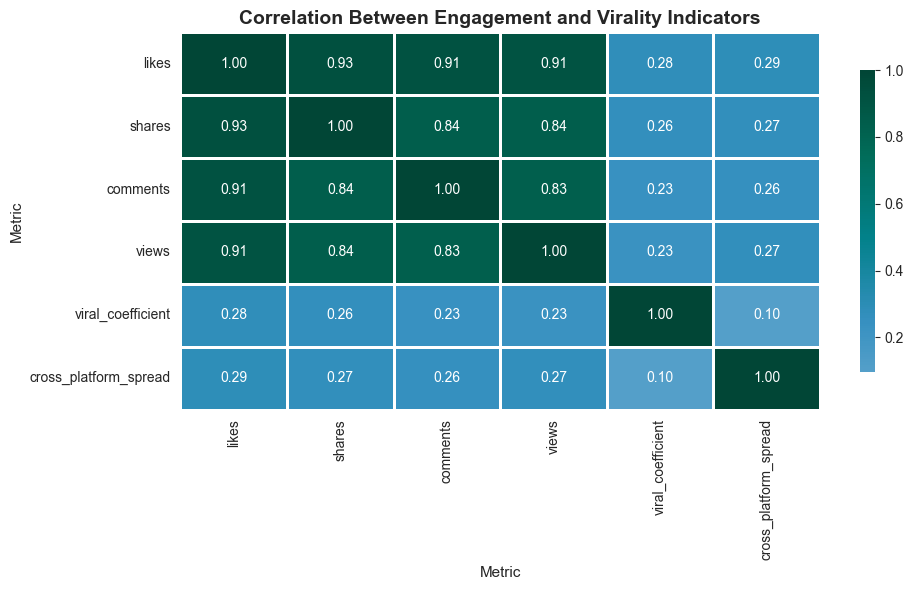

In [47]:
# visualisation: virality correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(virality_corr, annot=True, cmap="PuBuGn", center=0, fmt=".2f", linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Between Engagement and Virality Indicators", fontsize=14, fontweight="bold")
plt.xlabel("Metric", fontsize=11)
plt.ylabel("Metric", fontsize=11)
plt.tight_layout()
plt.show()


**Observation**: Posts that spread across more platforms are expected to show higher engagement. However, the relationship may not be perfect. Some content can perform very well on one platform without travelling much, while other content spreads even with moderate engagement.


**Key Takeaway**: High engagement helps, but it does not guarantee cross-platform spread. Sentiment, topic, audience behaviour, and platform culture may also matter.


## 7. Sentiment and Engagement Analysis

This section compares engagement by sentiment and checks whether the pattern changes across platforms.

#### Research Questions for This Section:
- Does positive content always perform better?
- How does sentiment affect engagement across different platforms?
- Is there a platform-specific sentiment advantage?

#### Step 12: Does positive content always perform better?

Analysing engagement metrics grouped by sentiment label and platform.

Functions used:
1. groupby()
2. mean()
3. unstack()


In [28]:
print("Average Engagement by Sentiment:")
sentiment_engagement = file.groupby("sentiment_category")[["likes", "shares", "comments"]].mean().round(2)
print(sentiment_engagement)

Average Engagement by Sentiment:
                     likes  shares  comments
sentiment_category                          
Negative            329.02   47.46     28.53
Neutral             340.06   51.05     28.65
Positive            378.03   56.97     32.11


In [29]:
print("Average Likes by Sentiment and Platform:")
sentiment_platform = file.groupby(["platform", "sentiment_category"])["likes"].mean().unstack()
sentiment_platform.round(2)


Average Likes by Sentiment and Platform:


sentiment_category,Negative,Neutral,Positive
platform,,,
Facebook,224.98,232.20,240.69
Instagram,302.14,334.05,367.67
Reddit,34.54,36.94,39.55
TikTok,571.73,553.02,556.83
Twitter,169.51,177.43,198.46
YouTube,1235.18,1292.14,1491.44


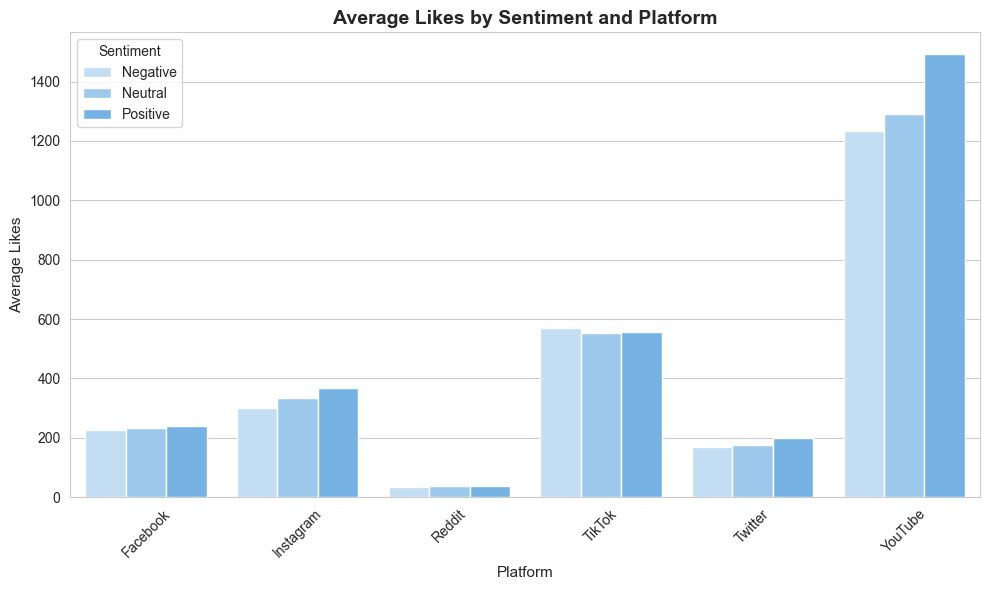

In [30]:
# visualisation: sentiment by platform
sentiment_melted = sentiment_platform.reset_index().melt(id_vars="platform", var_name="Sentiment", value_name="Average Likes")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sentiment_melted, x="platform", y="Average Likes", hue="Sentiment", palette=gradient[:len(sentiment_platform.columns)])

plt.title("Average Likes by Sentiment and Platform", fontsize=14, fontweight="bold")
plt.xlabel("Platform", fontsize=11)
plt.ylabel("Average Likes", fontsize=11)
plt.legend(title="Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation**: Positive content may receive more likes on many platforms, but this pattern is not universal. Neutral or negative content can also perform well when it creates discussion or strong reactions. The internet does love being peaceful, in theory.


**Key Takeaway**: Sentiment matters, but platform culture changes how sentiment works. A tone that gains attention on one platform may not perform the same way on another.


## 8. Account Authority Analysis

This section checks whether verified accounts and follower count are strongly related to engagement and viral coefficient.

#### Research Questions for This Section:
- Do verified and larger accounts always perform better?
- How strong is the relationship between follower count and engagement?
- Can smaller accounts still achieve virality?

#### Step 13: Do verified and larger accounts always perform better?

Comparing engagement and virality metrics between verified and non-verified accounts.

Functions used:
1. groupby()
2. mean()
3. corr()
4. scatter()


In [31]:
print("Average Engagement by Verification Status:")
verified_compare = file.groupby("verified")[["likes", "shares", "comments", "views"]].mean().round(2)
verified_compare.index = ["Not Verified", "Verified"]
print(verified_compare)


Average Engagement by Verification Status:
                likes  shares  comments      views
Not Verified   283.36   42.21     24.03    7800.59
Verified      6185.35  923.54    535.00  173052.35


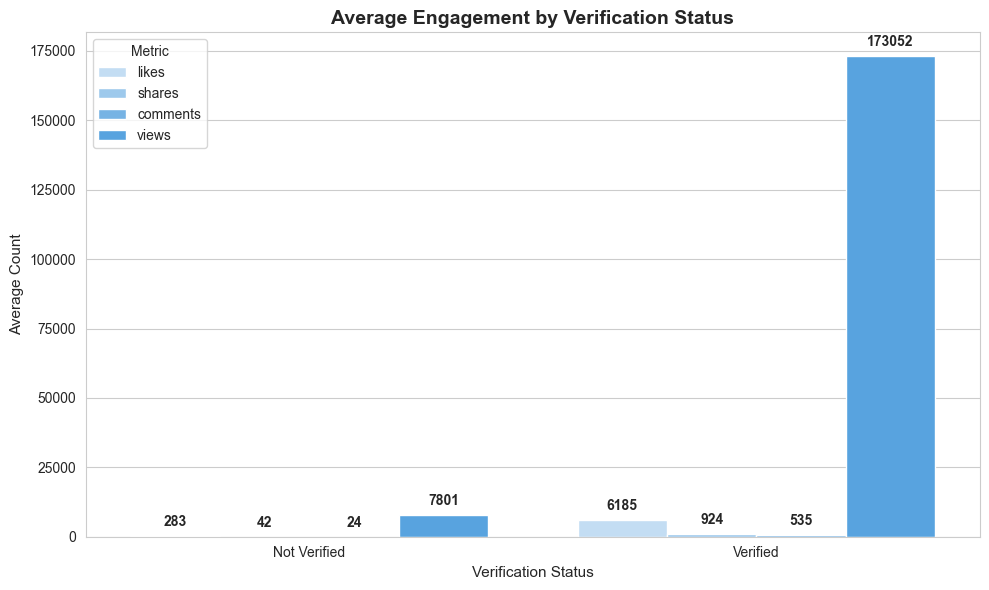

In [32]:
# visualisation: verification status
verified_compare["Status"] = ["Not Verified", "Verified"]
verified_melted = verified_compare.reset_index(drop=True).melt(id_vars="Status", var_name="Metric", value_name="Average")
verified_melted.rename(columns={"verified": "Status"}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=verified_melted, x="Status", y="Average", hue="Metric", palette=gradient[:4])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Engagement by Verification Status", fontsize=14, fontweight="bold")
plt.xlabel("Verification Status", fontsize=11)
plt.ylabel("Average Count", fontsize=11)
plt.tight_layout()
plt.show()


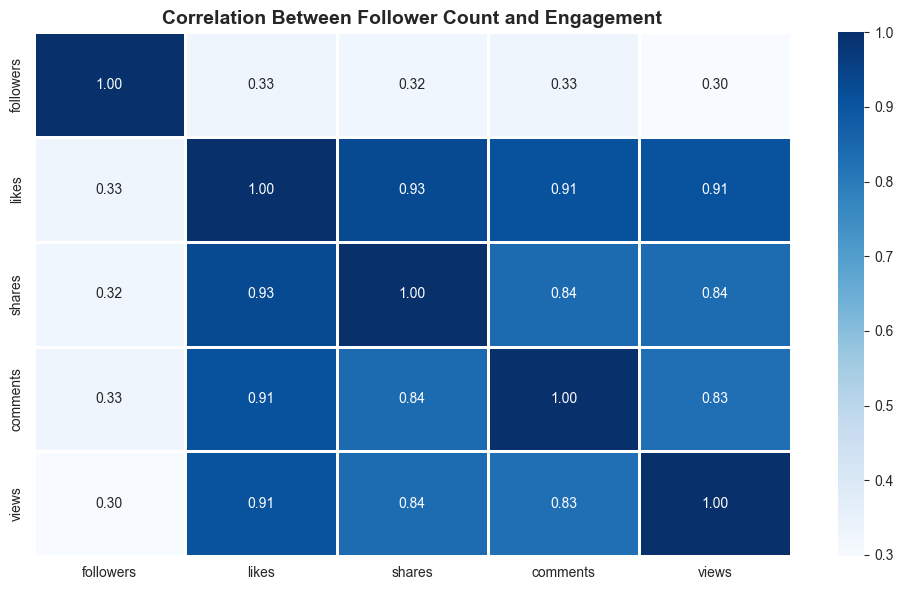

In [44]:
# visualisation: follower correlation
follower_corr = file[["followers", "likes", "shares", "comments", "views"]].corr().round(3)

plt.figure(figsize=(10, 6))
sns.heatmap(follower_corr, annot=True, cmap="Blues", fmt=".2f", linewidths=1)
plt.title("Correlation Between Follower Count and Engagement", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


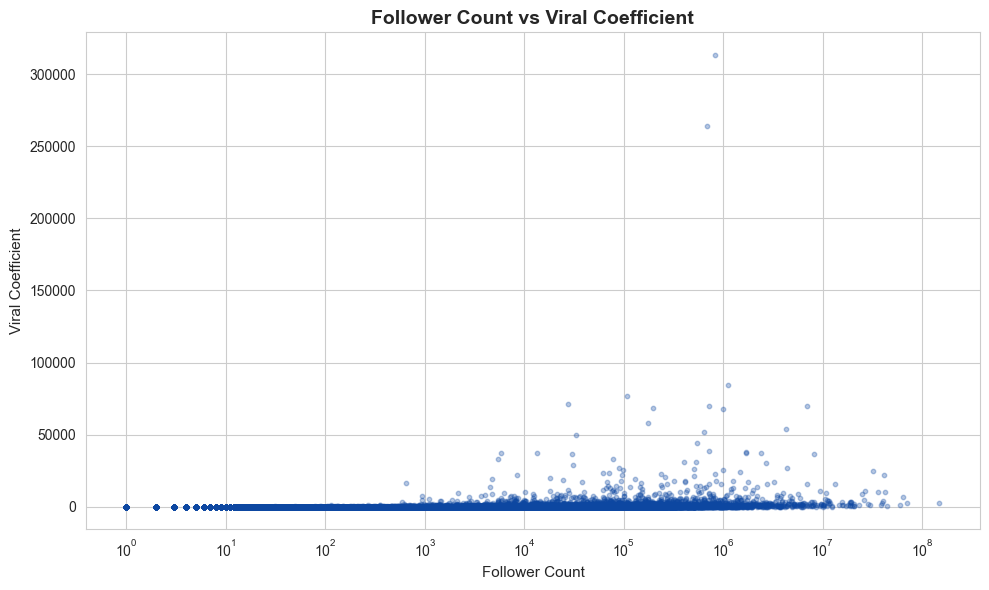

In [34]:
# visualisation: follower vs virality
plt.figure(figsize=(10, 6))
plt.scatter(file["followers"], file["viral_coefficient"], alpha=0.3, s=10, c=primary)
plt.title("Follower Count vs Viral Coefficient", fontsize=14, fontweight="bold")
plt.xlabel("Follower Count", fontsize=11)
plt.ylabel("Viral Coefficient", fontsize=11)
plt.xscale("log")
plt.tight_layout()
plt.show()


**Observation**: Verified accounts may receive higher average engagement, but follower count may not explain everything. Some smaller accounts can still have strong viral coefficients, while large accounts may perform only moderately.


**Key Takeaway**: A large audience gives an advantage, but it does not fully control virality. Content, timing, platform culture, and audience reaction still matter.


## 9. Virality Analysis

This section defines viral content as the top 10% of posts by viral coefficient. It then compares viral and non-viral content across engagement, topic, and sentiment.

#### Research Questions for This Section:
- What factors seem to separate viral posts from non-viral posts?
- Which topics and sentiments appear most among viral content?
- Is virality concentrated or distributed?

#### Step 14: What factors seem to separate viral posts from non-viral posts?

Segmenting the dataset at the 90th percentile of viral coefficient for comparison.

Functions used:
1. quantile()
2. boolean indexing
3. value_counts()
4. DataFrame()


In [35]:
# define viral content (top 10%)
viral_threshold = file["viral_coefficient"].quantile(0.9)
viral = file[file["viral_coefficient"] >= viral_threshold]
non_viral = file[file["viral_coefficient"] < viral_threshold]

print(f"Viral posts [top 10%]: {len(viral)}")
print(f"Non-viral posts: {len(non_viral)}")


Viral posts [top 10%]: 15004
Non-viral posts: 134996


In [36]:
print("Viral vs Non-Viral Content Profile:")
viral_profile = pd.DataFrame({
    "Viral": viral[["likes", "shares", "comments", "views", "followers"]].mean(),
    "Non-Viral": non_viral[["likes", "shares", "comments", "views", "followers"]].mean()
}).round(2)
print(viral_profile)


Viral vs Non-Viral Content Profile:
               Viral  Non-Viral
likes        3303.36      26.67
shares        495.08       3.67
comments      283.65       2.01
views       91276.70     733.48
followers  218764.65    4059.18


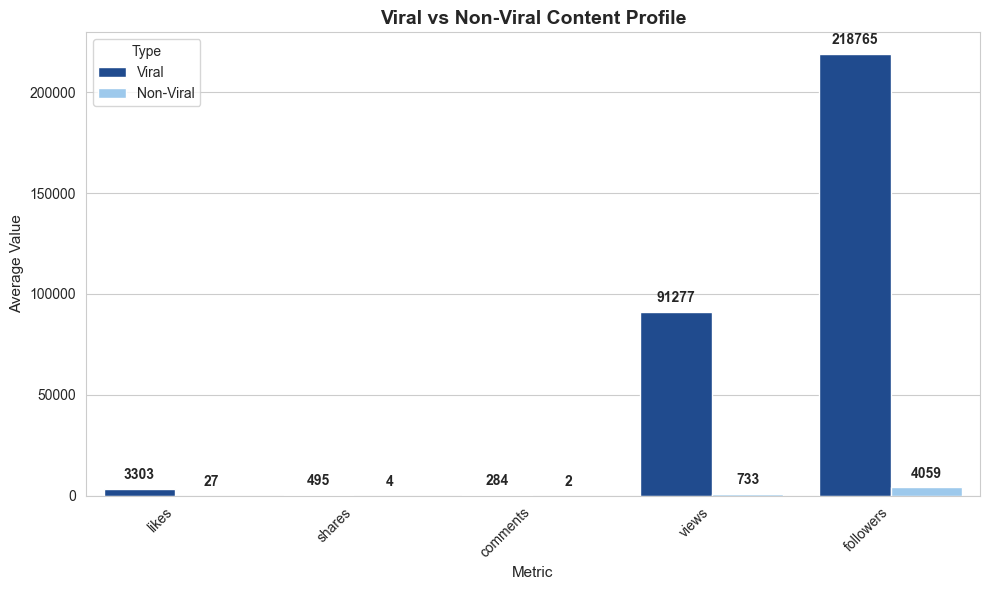

In [37]:
# visualisation: viral vs non-viral
viral_melted = viral_profile.reset_index().melt(id_vars="index", var_name="Type", value_name="Average")
viral_melted.rename(columns={"index": "Metric"}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=viral_melted, x="Metric", y="Average", hue="Type", palette=[primary, secondary])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10, fontweight="bold", padding=5)

plt.title("Viral vs Non-Viral Content Profile", fontsize=14, fontweight="bold")
plt.xlabel("Metric", fontsize=11)
plt.ylabel("Average Value", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [38]:
# topic viral ratio
viral_topic_dist = viral["topic"].value_counts(normalize=True)
non_viral_topic_dist = non_viral["topic"].value_counts(normalize=True)

topic_viral_ratio = (viral_topic_dist / non_viral_topic_dist).sort_values(ascending=False)
print("Topic Viral Ratio (viral % / non-viral %):")
print(topic_viral_ratio.head(10).round(2))


Topic Viral Ratio (viral % / non-viral %):
topic
Finance          1.06
Climate          1.05
Fashion          1.03
Education        1.03
Politics         1.01
Science          1.01
Entertainment    1.00
Sports           1.00
Health           0.99
Food             0.99
Name: proportion, dtype: float64


In [39]:
print("Sentiment Distribution: Viral vs Non-Viral:")
viral_sentiment = viral["sentiment_category"].value_counts(normalize=True)
non_viral_sentiment = non_viral["sentiment_category"].value_counts(normalize=True)

sentiment_comparison = pd.DataFrame({
    "Viral": viral_sentiment,
    "Non-Viral": non_viral_sentiment
}).round(3)
print(sentiment_comparison)


Sentiment Distribution: Viral vs Non-Viral:
                    Viral  Non-Viral
sentiment_category                  
Positive            0.475      0.448
Neutral             0.291      0.302
Negative            0.234      0.250


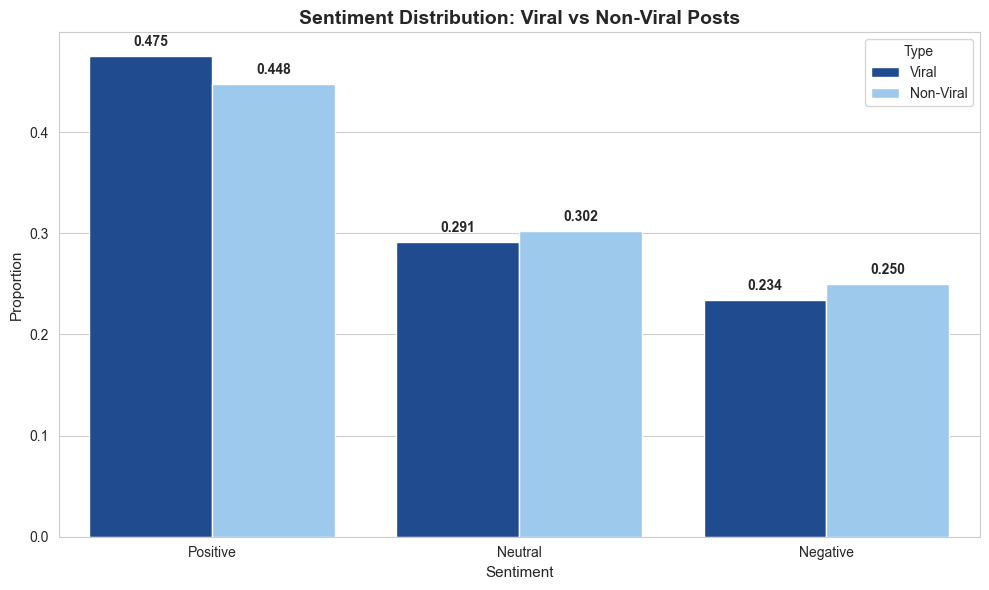

In [40]:
# visualisation: sentiment viral vs non-viral
sentiment_comp_melted = sentiment_comparison.reset_index().melt(id_vars="sentiment_category", var_name="Type", value_name="Proportion")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sentiment_comp_melted, x="sentiment_category", y="Proportion", hue="Type", palette=[primary, secondary])

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, fontweight="bold", padding=5)

plt.title("Sentiment Distribution: Viral vs Non-Viral Posts", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment", fontsize=11)
plt.ylabel("Proportion", fontsize=11)
plt.tight_layout()
plt.show()


**Observation**: Viral content is likely to show much higher engagement than non-viral content. Entertainment, gaming, and technology may appear more often among viral posts. Positive sentiment may also be slightly more common, but it is unlikely to be the only deciding factor.


**Key Takeaway**: Virality often follows a winner-take-most pattern. A small share of posts collects a large share of attention, which is unfair but also very on-brand for social media.


## 10. Key Findings and Insights

### Major Patterns Identified

#### Step 15: What are the main patterns from the analysis?

#### 1. Platform attention profiles differ
- YouTube may dominate view counts.
- TikTok may generate high like volumes.
- Twitter often supports sharing behaviour.
- Reddit encourages discussion through comments.

#### 2. Topic and platform work together
- Entertainment, technology, and gaming appear strongly across platforms.
- Different platforms favour different topics.
- Discussion volume changes by topic and audience type.

#### 3. Timing has some influence
- Certain posting hours may be linked with higher engagement.
- Weekend posts may receive more engagement than weekday posts.
- Timing is useful, but it cannot save weak content.

#### 4. Virality is linked with spread and engagement
- Cross-platform spread is associated with stronger engagement.
- Positive sentiment may receive more likes, but not always more shares.
- Follower count helps, but does not guarantee virality.

#### 5. The attention economy is not simple
- No single factor explains online success.
- Platform norms, topic type, timing, sentiment, and account authority all play a role.
- The interaction between these factors is likely more important than any one variable.


## 11. Statistical Summary

#### Step 16: What are the key numbers from the dataset?

This final statistical summary brings together the main values for sample size, platform count, engagement, virality, and account authority.


In [41]:
# statistical summary
sample_size = len(file)
platform_count = file["platform"].nunique()
topic_count = file["topic"].nunique()
mean_likes = file["likes"].mean()
mean_shares = file["shares"].mean()
mean_comments = file["comments"].mean()
mean_views = file["views"].mean()
mean_viral_coefficient = file["viral_coefficient"].mean()
mean_spread = file["cross_platform_spread"].mean()
verified_percentage = file[file["verified"] == True].shape[0] / sample_size * 100

print("KEY STATISTICS SUMMARY")
print("="*70)
print(f"\nSample Size: {sample_size} posts")
print(f"Platforms Covered: {platform_count}")
print(f"Topics Covered: {topic_count}")
print("\nAverage Engagement:")
print(f"  Likes: {mean_likes:.2f}")
print(f"  Shares: {mean_shares:.2f}")
print(f"  Comments: {mean_comments:.2f}")
print(f"  Views: {mean_views:.2f}")
print("\nVirality Indicators:")
print(f"  Average Viral Coefficient: {mean_viral_coefficient:.2f}")
print(f"  Average Cross-Platform Spread: {mean_spread:.2f}")
print("\nAccount Authority:")
print(f"  Verified Accounts: {verified_percentage:.1f}%")


KEY STATISTICS SUMMARY

Sample Size: 150000 posts
Platforms Covered: 6
Topics Covered: 15

Average Engagement:
  Likes: 354.42
  Shares: 52.82
  Comments: 30.18
  Views: 9790.22

Virality Indicators:
  Average Viral Coefficient: 55.55
  Average Cross-Platform Spread: 0.01

Account Authority:
  Verified Accounts: 1.2%


## 12. Limitations

#### Step 17: What should be kept in mind while reading this analysis?

1. **Dataset limitations**: the dataset may be synthetic or simplified, so it may not fully match real-world platform behaviour.

2. **Platform differences**: each platform measures engagement differently. A view on YouTube may not mean the same thing as a view on TikTok.

3. **Missing context**: the dataset may not include full user background or detailed post text for deeper interpretation.

4. **Correlation and causation**: the notebook observes relationships, but it does not prove cause and effect.

5. **Time period**: if the data covers a limited time frame, longer trends and seasonal changes may be missed.

6. **Language bias**: even when multiple languages are included, some languages may still be over-represented.


## 13. Conclusion

#### Step 18: What does the full analysis suggest?

### Summary

This analysis shows that online attention is shaped by a mix of platform design, topic type, timing, sentiment, and account authority. Different platforms reward different kinds of engagement, so a post that performs well in one place may not perform the same way elsewhere.

The strongest point from the notebook is that virality is not explained by one simple factor. High engagement, strong topics, and larger accounts may help, but they do not guarantee success. Cross-platform spread seems to be connected with stronger engagement, but correlation is not proof of causation.

### Implications

1. **For Content Creators**: Understanding platform-specific dynamics is more valuable than chasing universal virality. Content should be tailored to the platform where it will be shared.

2. **For Platform Analysts**: Engagement metrics tell different stories depending on the platform. A holistic view requires looking at likes, shares, comments, and views together rather than in isolation.

3. **For Researchers**: The attention economy is multi-dimensional. Future work should explore longitudinal patterns and control for confounding variables to better isolate causal mechanisms.

### Final Thoughts

The attention economy works like a very crowded school corridor. Everyone is talking, a few people are somehow louder than everyone else, and nobody is fully sure why one joke becomes famous. Data cannot explain everything, but it helps us see the patterns more clearly.
